In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

In [2]:
class GFETDiracProcessor:

    def __init__(
        self,
        folder_path,
        channels_to_omit,
        channel_colors,
        func_steps,
        analyte_steps,
        func_title,
        analyte_title
    ):

        self.folder_path = folder_path
        self.channels_to_plot = [i for i in range(16) if i not in channels_to_omit]
        if channel_colors:
            self.channel_colors = channel_colors
        else:
            colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
            first_16_colors = [colors[i % len(colors)] for i in range(16)]
            self.channel_colors = first_16_colors

        self.func_steps = func_steps
        self.analyte_steps = analyte_steps

        self.func_title = func_title
        self.analyte_title = analyte_title

        self.func_files = []
        self.analyte_files = []

    # -----------------------------
    # FILE GATHERING
    # -----------------------------

    def gather_files(self):

        self.func_files = []
        self.analyte_files = []

        for filename in sorted(os.listdir(self.folder_path)):

            if filename.startswith("analyte"):
                self.analyte_files.append(filename)

            elif filename.startswith("func"):
                print(filename)
                self.func_files.append(filename)

    # -----------------------------
    # TRANSCONDUCTANCE
    # -----------------------------

    def compute_transconductance(self, vg, idrain):

        slope = np.gradient(idrain, vg)

        # windowed average (size 7)
        kernel = np.ones(7) / 7
        slope = np.convolve(slope, kernel, mode="same")

        pos_idx = np.argmax(slope)
        neg_idx = np.argmin(slope)

        return vg[pos_idx], vg[neg_idx]

    # -----------------------------
    # DIRAC EXTRACTION
    # -----------------------------

    def extract_dirac(self, files):

        fwd = np.zeros((len(files), 16))
        rev = np.zeros((len(files), 16))

        for i, path in enumerate(files):

            df = pd.read_csv(self.folder_path + path)

            dirac_rows = df[df["DIRAC_SWEEP_IDX"].notna()]

            fwd_cols = [f"DIRAC_V_FWD_CH{i}" for i in range(16)]
            rev_cols = [f"DIRAC_V_REV_CH{i}" for i in range(16)]

            for j, ch in enumerate(range(16)): # enumerate(self.channels_to_plot):

                fwd_vals = dirac_rows[fwd_cols[ch]].to_numpy()
                rev_vals = dirac_rows[rev_cols[ch]].to_numpy()

                fwd[i, j] = fwd_vals[-1]
                rev[i, j] = rev_vals[-1]

        return fwd, rev

    # -----------------------------
    # TRANSCONDUCTANCE EXTRACTION
    # -----------------------------

    def extract_transconductance(self, files):

        pos_trans = np.zeros((len(files), len(self.channels_to_plot)))
        neg_trans = np.zeros((len(files), len(self.channels_to_plot)))

        for i, path in enumerate(files):

            df = pd.read_csv(self.folder_path + path)

            last_sweep = int(df["SWEEP_IDX"].iloc[-1] - 1)

            for j, ch in enumerate(range(16)): # enumerate(self.channels_to_plot):

                subset = df.loc[
                    df["SWEEP_IDX"] == last_sweep,
                    ["V_GATE", f"I_CH{ch}"]
                ]

                vg = subset["V_GATE"].to_numpy()
                idrain = subset[f"I_CH{ch}"].to_numpy()

                pos, neg = self.compute_transconductance(vg, idrain)

                pos_trans[i, j] = pos
                neg_trans[i, j] = neg

        return pos_trans, neg_trans

    # -----------------------------
    # FUNCTIONALIZATION PLOTS
    # -----------------------------

    def plot_functionalization(self):

        self.gather_files()

        fwd, rev = self.extract_dirac(self.func_files)

        x = np.arange(len(self.func_files))

        for data, label in [(fwd, "Forward"), (rev, "Reverse")]:

            plt.figure(figsize=(7,4))

            for col in self.channels_to_plot: # range(data.shape[1]):

                plt.plot(
                    x,
                    data[:,col],
                    marker="o",
                    color = self.channel_colors[col],
                    label=f"CH {col}",
                )

            plt.xlabel("Functionalization Step")
            plt.ylabel("Dirac Voltage (V)")
            plt.xticks(x, self.func_steps[:len(self.func_files)])
            plt.grid(True)

            plt.legend(
                fontsize=9,
                loc="center left",
                bbox_to_anchor=(1.02,0.5)
            )

            plt.title(f"{self.func_title}, {label} Sweep")
            plt.tight_layout()
            plt.show()

    # -----------------------------
    # ANALYTE PLOTS
    # -----------------------------

    def plot_analyte_abs(self):
    
        self.gather_files()
    
        fwd, rev = self.extract_dirac(self.analyte_files)

        base_fwd, base_rev = self.extract_dirac([self.func_files[-1]])
        base_fwd = base_fwd[0]
        base_rev = base_rev[0]
    
        x = np.arange(len(self.analyte_files))
    
        for data, label, baseline in [(fwd, "Forward", base_fwd), (rev, "Reverse", base_rev)]:
    
            plt.figure(figsize=(7,4))
    
            for col in self.channels_to_plot:
                plt.plot(
                    x,
                    data[:, col],
                    marker="o",
                    color=self.channel_colors[col],
                    label=f"CH {col}",
                )
                
                plt.axhline(baseline[col], linestyle="--", color=self.channel_colors[col])

    
            plt.xlabel("Analyte Concentration")
            plt.ylabel("Dirac Voltage (V)")
            plt.xticks(x, self.analyte_steps[:len(self.analyte_files)])
            plt.grid(True)
    
            baseline_line = Line2D([0], [0], color='black', linestyle='--', label='Baseline')
            handles, labels = plt.gca().get_legend_handles_labels()
            handles.append(baseline_line)
            plt.legend(handles=handles, fontsize=9, loc="center left", bbox_to_anchor=(1.02,0.5))
            plt.title(f"{self.analyte_title}, {label} Sweep")
            plt.tight_layout()
            plt.show()



            
    def plot_analyte_abs_change(self):
    
        self.gather_files()
    
        fwd, rev = self.extract_dirac(self.analyte_files)
    
        base_fwd, base_rev = self.extract_dirac([self.func_files[-1]])
        
        base_fwd = base_fwd[0]
        base_rev = base_rev[0]
    
        delta_fwd = fwd - base_fwd
        delta_rev = rev - base_rev
    
        x = np.arange(len(self.analyte_files))
    
        for data, label in [(delta_fwd, "Forward"), (delta_rev, "Reverse")]:
    
            plt.figure(figsize=(7,4))
    
            for col in self.channels_to_plot:
                plt.plot(
                    x,
                    data[:, col],
                    marker="o",
                    color=self.channel_colors[col],
                    label=f"CH {col}",
                )
    
            plt.axhline(0, linestyle="--", color='black', label='Baseline')  # baseline reference
    
            plt.xlabel("Analyte Concentration")
            plt.ylabel("Dirac Shift (V)")
            plt.xticks(x, self.analyte_steps[:len(self.analyte_files)])
            plt.grid(True)
    
            plt.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02,0.5))
            plt.title(f"{self.analyte_title} (Δ from baseline), {label}")
            plt.tight_layout()
            plt.show()

    
    def plot_analyte_norm(self):
    
        self.gather_files()
    
        fwd, rev = self.extract_dirac(self.analyte_files)
    
        base_fwd, base_rev = self.extract_dirac([self.func_files[-1]])
        base_fwd = base_fwd[0]
        base_rev = base_rev[0]
    
        norm_fwd = (fwd - base_fwd) / base_fwd * 100
        norm_rev = (rev - base_rev) / base_rev * 100
    
        x = np.arange(len(self.analyte_files))
    
        for data, label in [(norm_fwd, "Forward"), (norm_rev, "Reverse")]:
    
            plt.figure(figsize=(7,4))
    
            for col in self.channels_to_plot:
                plt.plot(
                    x,
                    data[:, col],
                    marker="o",
                    color=self.channel_colors[col],
                    label=f"CH {col}",
                )
    
            plt.axhline(0, linestyle="--", color='black', label='Baseline')
    
            plt.xlabel("Analyte Concentration")
            plt.ylabel("Dirac Shift (%)")
            plt.xticks(x, self.analyte_steps[:len(self.analyte_files)])
            plt.grid(True)
    
            plt.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02,0.5))
            plt.title(f"Normalized {self.analyte_title}, {label}")
            plt.tight_layout()
            plt.show()


    def plot_last_dirac_curves(self):
        """
        Plot the last complete Dirac sweep from each CSV file. Not meant specifically for functionalization but it plots all of them
        """
    
        self.gather_files()

        all_dirac = []
        
        for filename in sorted(os.listdir(self.folder_path)):
                
            if not filename.lower().endswith(".csv"): continue

            print(filename)
            df = pd.read_csv(self.folder_path + filename)

            all_dirac = []
            dirac_rows = df[df["DIRAC_SWEEP_IDX"].notna()]                
    
            last_sweep = int(df["SWEEP_IDX"].iloc[-1] - 1)
    
            plt.figure(figsize=(8, 5))
    
            for ch in self.channels_to_plot:
    
                subset = df.loc[
                    df["SWEEP_IDX"] == last_sweep,
                    ["V_GATE", f"I_CH{ch}"]
                ]

                dirac_val = dirac_rows[f"DIRAC_V_FWD_CH{ch}"].iloc[-1]
                all_dirac.append(dirac_val)  


                vg = subset["V_GATE"].to_numpy()
                idrain = subset[f"I_CH{ch}"].to_numpy()
                
                turn_idx = np.argmax(vg)
                
                plt.plot(
                    vg[:turn_idx+1],
                    idrain[:turn_idx+1] * 1e6,
                    color=self.channel_colors[ch],
                    label=f"CH {ch}"
                )

                # plt.plot(
                #     subset["V_GATE"],
                #     subset[f"I_CH{ch}"] * 1e6,
                #     color=self.channel_colors[ch],
                #     label=f"CH {ch}"
                # )
    
            plt.xlabel("Gate Voltage (V)")
            plt.ylabel("Drain Current (μA)")
            plt.title(f"{filename}\n Micro-channel Initial IV Curves (non-functionalized)")
            plt.ylim(bottom=0)
            plt.xlim(min(subset["V_GATE"]), max(subset["V_GATE"]))
    
            plt.legend(
                fontsize=8,
                loc="center left",
                bbox_to_anchor=(1.02, 0.5)
            )
    
            plt.tight_layout()
            plt.show()
        
        
            plt.figure(figsize=(6, 1.8))
            
            # 1D line position
            y = np.zeros(len(all_dirac))
            
            # channel colors aligned with your plotting convention
            colors = [self.channel_colors[ch] for ch in self.channels_to_plot]
            
            # colored 1D points
            for val, c in zip(all_dirac, colors):
                plt.scatter(val, 0, color=c, s=80, marker='|', zorder=3)
            
            # mean + std (black whiskers)
            mean = np.mean(all_dirac)
            std = np.std(all_dirac)
            
            plt.errorbar(
                mean,
                0,
                xerr=std,
                fmt='o',
                color='black',
                ecolor='black',
                elinewidth=2,
                capsize=8,
                markersize=6,
                zorder=2,
                label='Mean ± 1σ'
            )
            
            plt.yticks([])
            plt.xlabel("Dirac Voltage (V)")
            plt.title(f"Dirac Voltage Distribution\nMean = {mean:.2f} V, σ = {std:.2f} V")
            ax = plt.gca()
            
            ax.xaxis.set_major_locator(ticker.MultipleLocator(0.01))
            ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
            # plt.xlim(min(subset["V_GATE"]), max(subset["V_GATE"]))          

    # loc="center left", bbox_to_anchor=(1.02, 0.5)

            
            plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
            plt.tight_layout()
            plt.show()

w7_d11_5min_postetch.csv


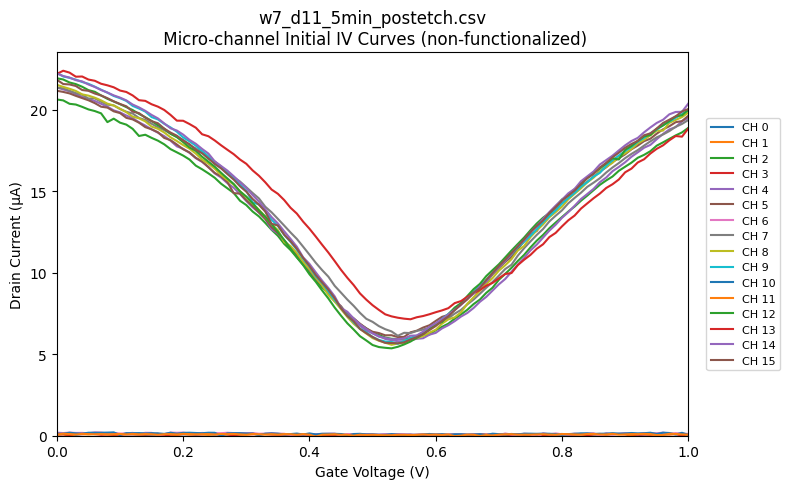

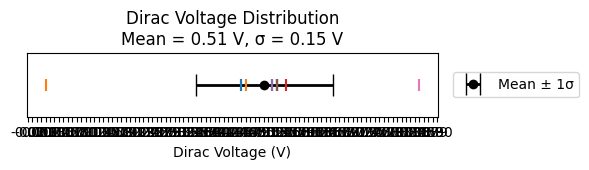

w7_d11_5min_postetch_postacetoneipa.csv


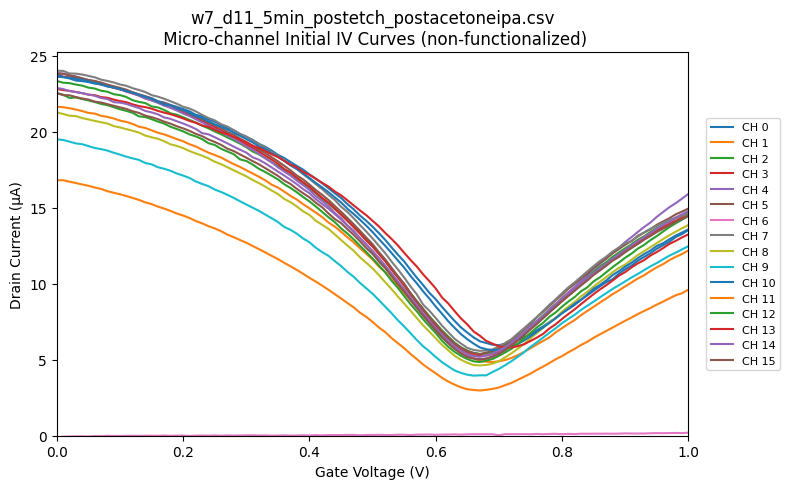

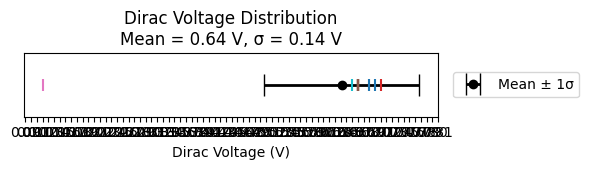

w7_d16_5min_postetch.csv


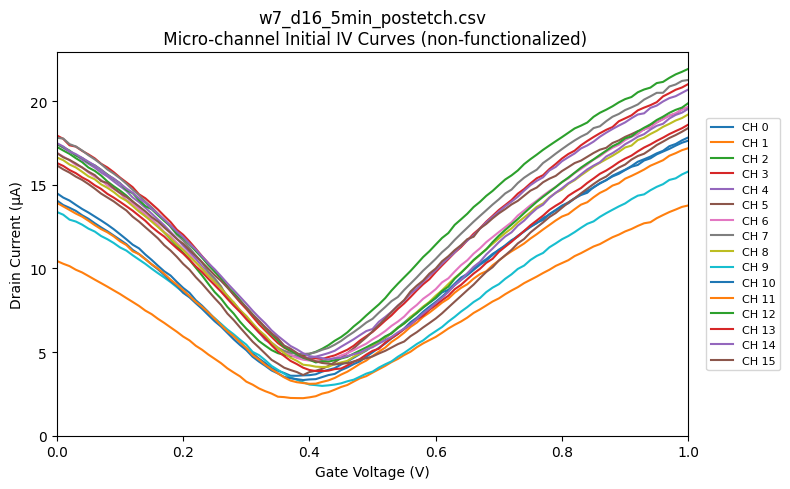

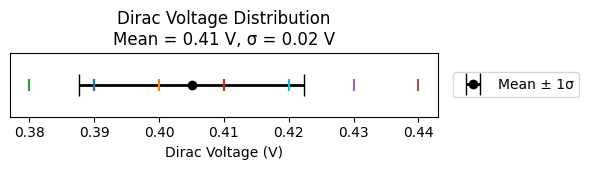

w7_d16_5min_postetch_postPGRemover.csv


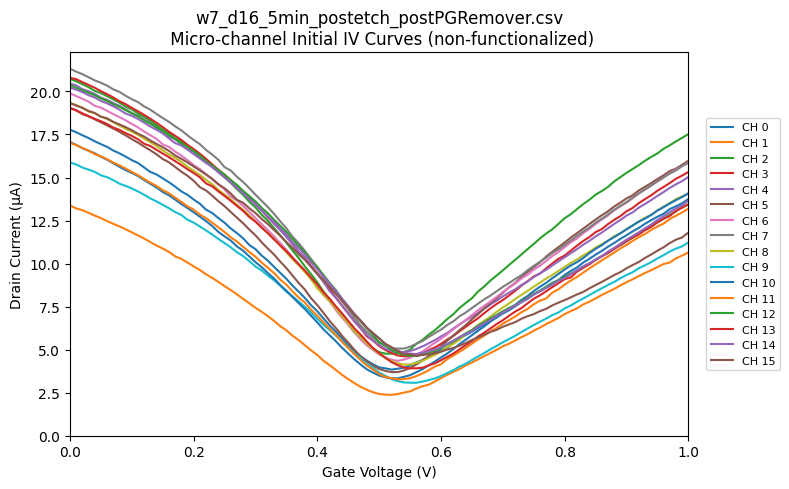

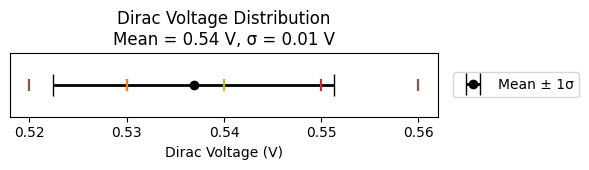

w7_d5_5min_postetch.csv


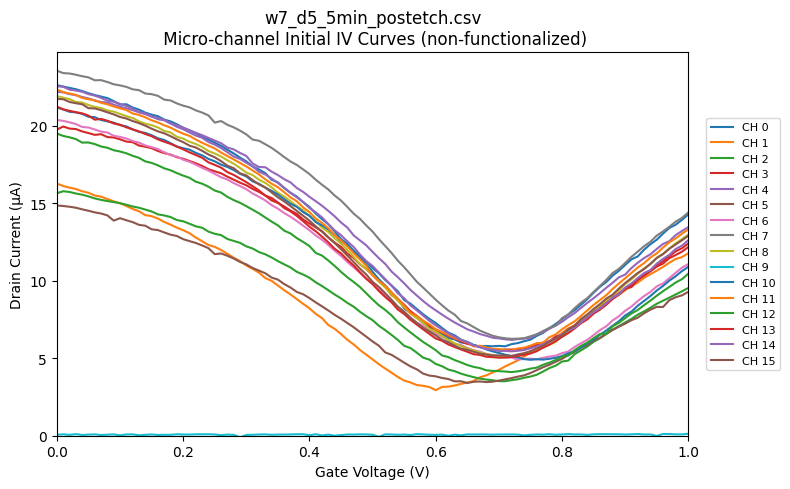

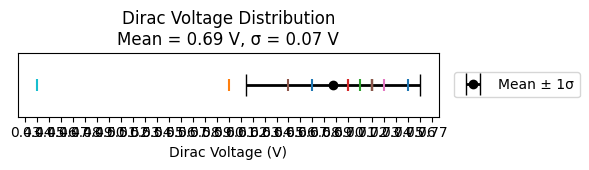

w7_d5_5min_postetch_postPGRemover.csv


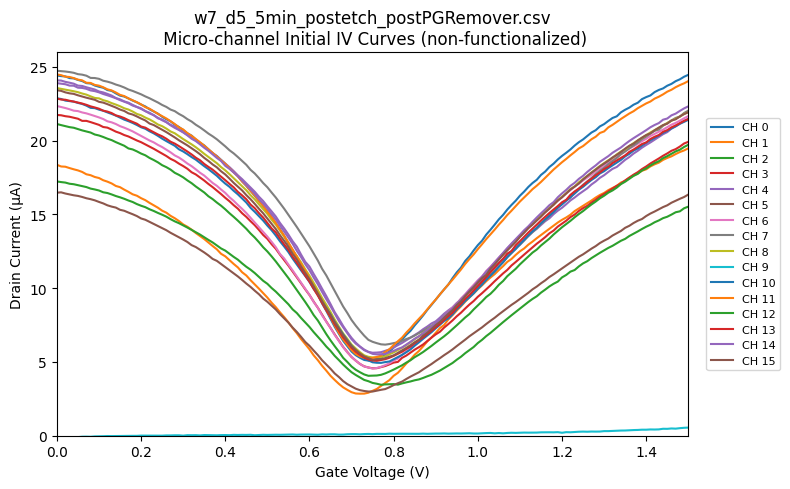

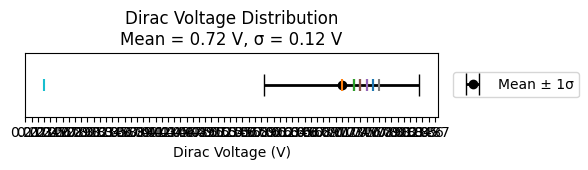

In [3]:
folder_path = "../data_pcb_smu/" + '2026-06-18 w7 PR_removal_acetonePG_tests/'

channels_to_omit = []
channel_colors = {}

# green = {8, 9, 12, 13, 14, 15}
# blue = {0, 1, 6, 10, 11}
# red = {2, 3, 4, 5, 7} 
# for i in range(16):
#     channel_colors[i] = 'green' if i in green else 'blue' if i in blue else 'red'

func_steps = [] # ["Initial", "PBASE-Oligo", "0.01X PBS Blank"]
analyte_steps = [] #["1uM"]
func_title = [] #"Functionalization Steps with PBASE-Oligos"
analyte_title = [] #"Dirac Shift with PBASE-Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

# processor.plot_functionalization()
# processor.plot_analyte_abs()
# processor.plot_analyte_abs_change()
# processor.plot_analyte_norm()

processor.plot_last_dirac_curves()

func1-w1d11-id.csv
func2-w1d11-ddt.csv
func3-w1d11-oligo.csv


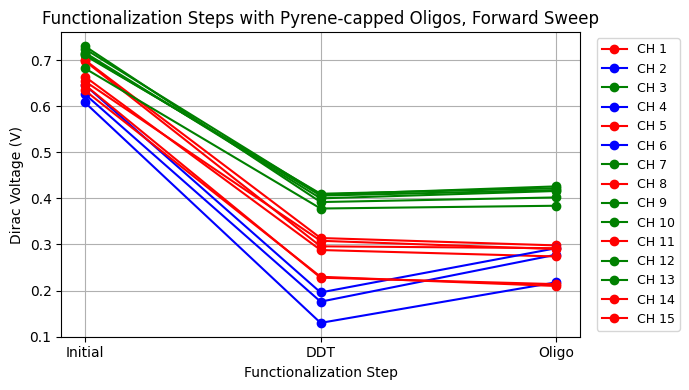

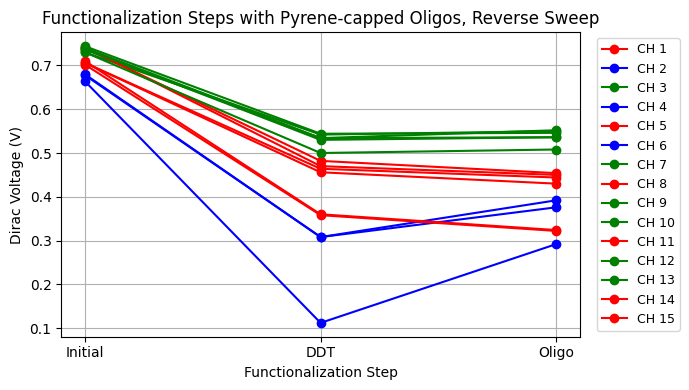

func1-w1d11-id.csv
func2-w1d11-ddt.csv
func3-w1d11-oligo.csv


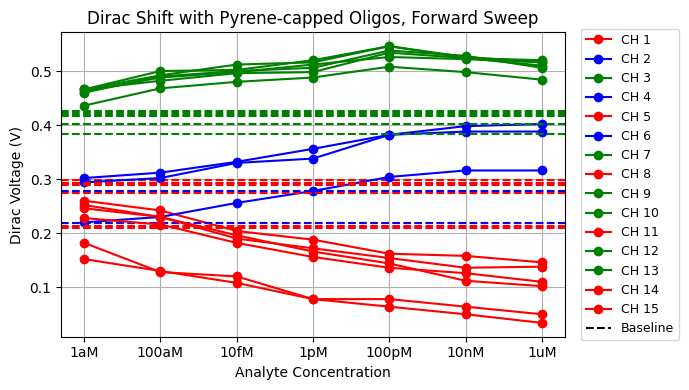

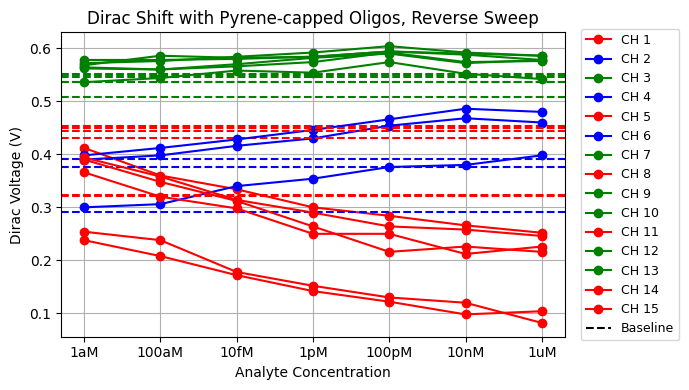

func1-w1d11-id.csv
func2-w1d11-ddt.csv
func3-w1d11-oligo.csv


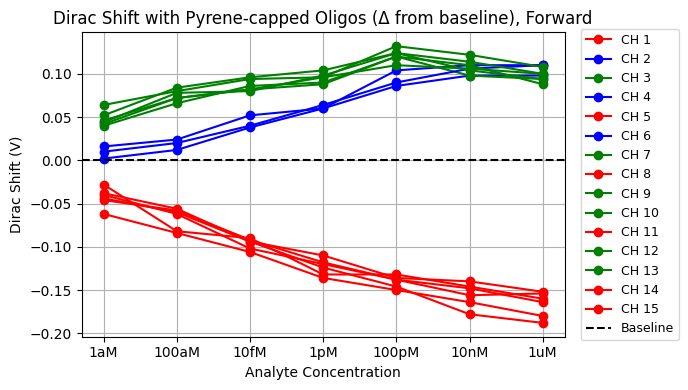

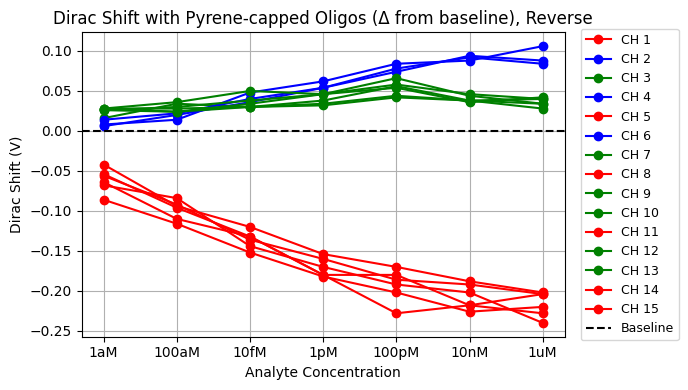

func1-w1d11-id.csv
func2-w1d11-ddt.csv
func3-w1d11-oligo.csv


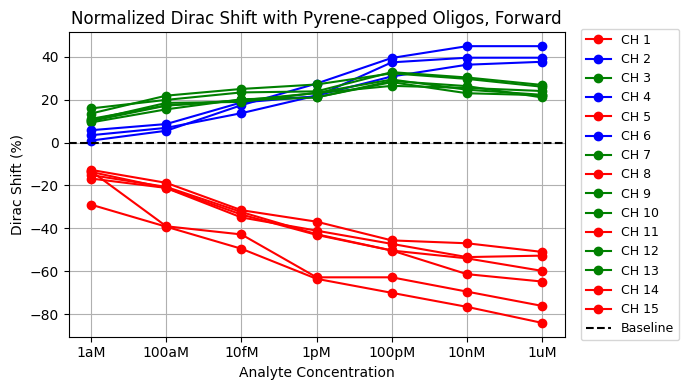

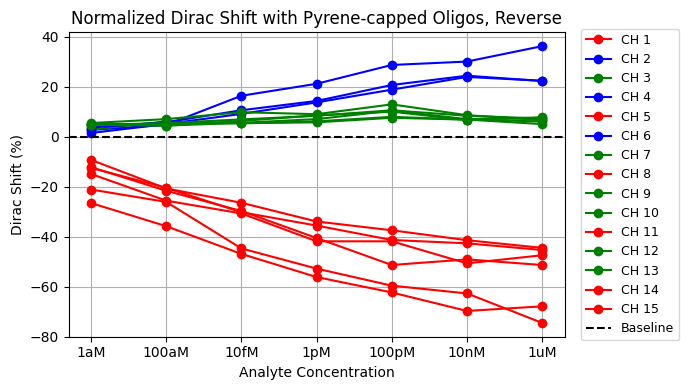

In [4]:
folder_path = "../data_pcb_smu/" + "2026-03-17 w1d11 dirac-tracking pyrene-capped pos-neg-ctrl/"
channels_to_omit = [0]
channel_colors = ['blue', 'red', 'blue', 'green', 'blue', 'red', 'blue', 'green', 'red', 'green', 'green', 'red', 'green', 'green', 'red', 'red']
func_steps = ["Initial", "DDT", "Oligo"]
analyte_steps = ["1aM", "100aM", "10fM", "1pM", "100pM", "10nM", "1uM"]
func_title = "Functionalization Steps with Pyrene-capped Oligos"
analyte_title = "Dirac Shift with Pyrene-capped Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w1d13-id.csv
func2-w1d13-ddt.csv
func3-w1d13-oligo.csv


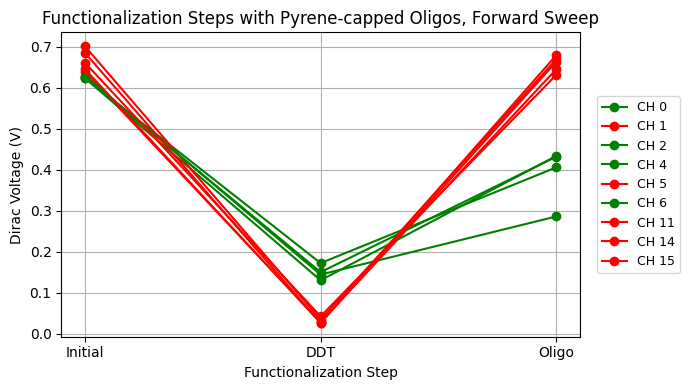

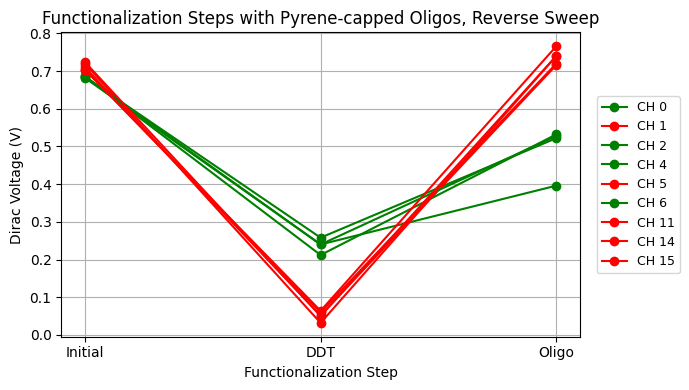

func1-w1d13-id.csv
func2-w1d13-ddt.csv
func3-w1d13-oligo.csv


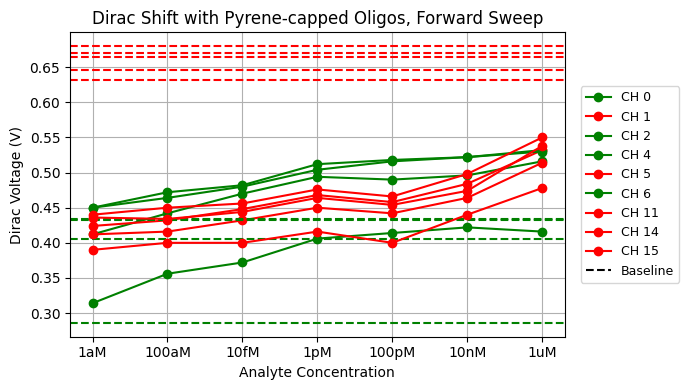

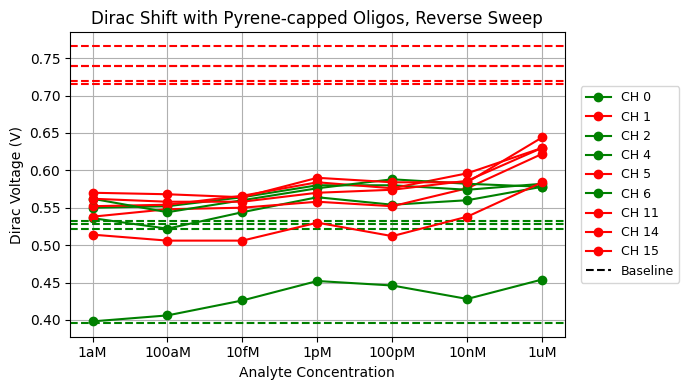

func1-w1d13-id.csv
func2-w1d13-ddt.csv
func3-w1d13-oligo.csv


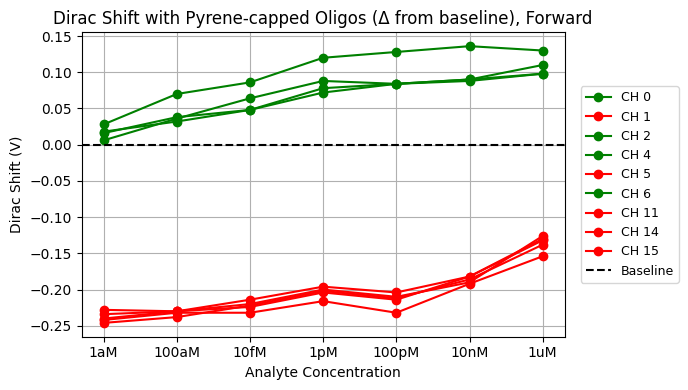

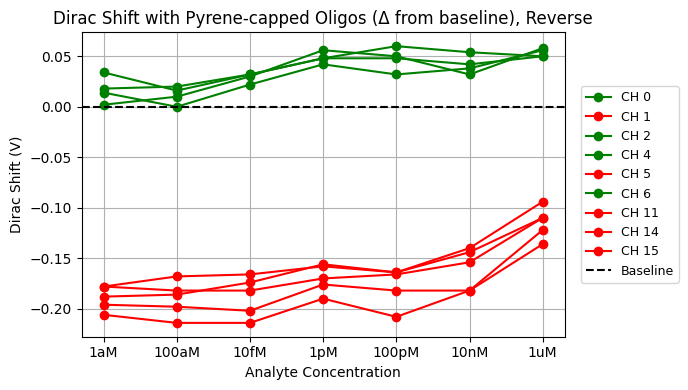

func1-w1d13-id.csv
func2-w1d13-ddt.csv
func3-w1d13-oligo.csv


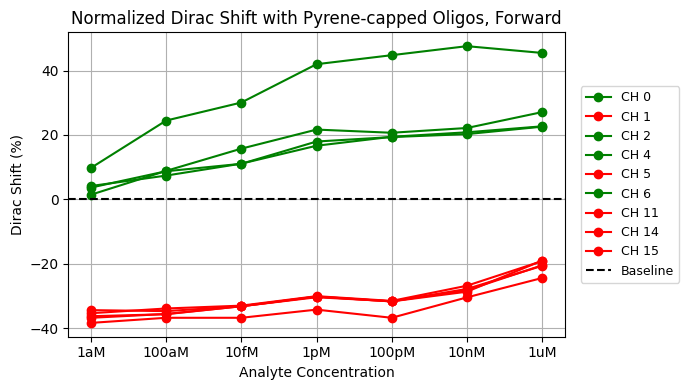

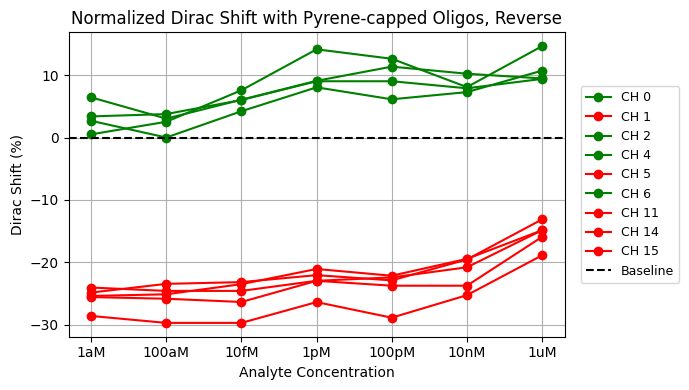

In [5]:
folder_path = "../data_pcb_smu/" + "2026-03-17 w1d13 dirac-tracking pyrene-capped pos-neg-ctrl/"
channels_to_omit = [3, 7, 9, 8, 10, 12, 13] # [1, 5, 8, 11, 14, 15]


# (1): NONE
# (2): Neg ctrl, scrambled oligo
# (3): Pos ctrl, complement oligo
# (4): NONE


# The respective channels are:
# (1): NONE
# (2): 1, 5, 8, 11, 14, 15
# (3): 0, 2, 4, 6
# (4): 3, 7, 9, 10, 12, 13

channel_colors = ['green', 'red', 'green', 'black', 'green', 'red', 'green', 'black', 'red', 'black', 'black', 'red', 'black', 'black', 'red', 'red']
func_steps = ["Initial", "DDT", "Oligo"]
analyte_steps = ["1aM", "100aM", "10fM", "1pM", "100pM", "10nM", "1uM"]
func_title = "Functionalization Steps with Pyrene-capped Oligos"
analyte_title = "Dirac Shift with Pyrene-capped Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w1d06-id.csv
func2-w1d06-oligo.csv


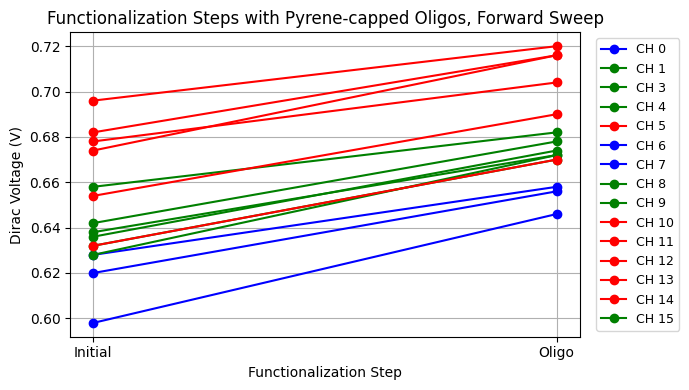

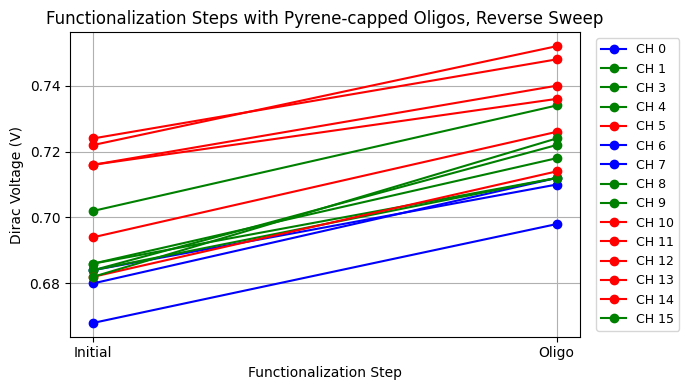

func1-w1d06-id.csv
func2-w1d06-oligo.csv


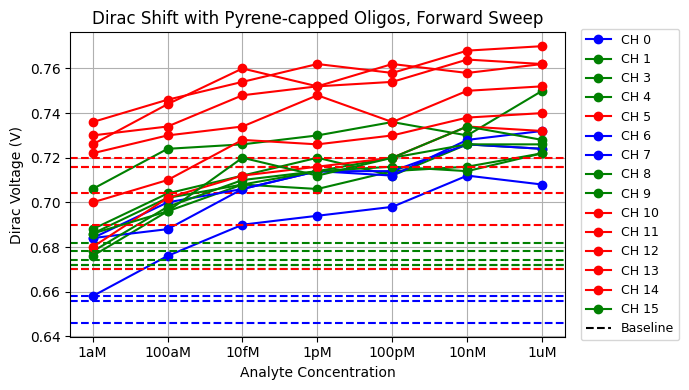

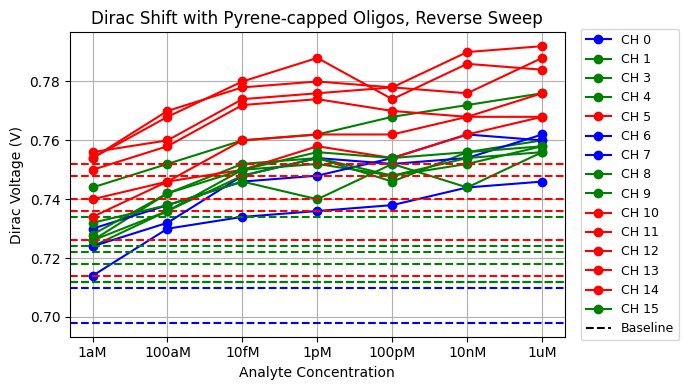

func1-w1d06-id.csv
func2-w1d06-oligo.csv


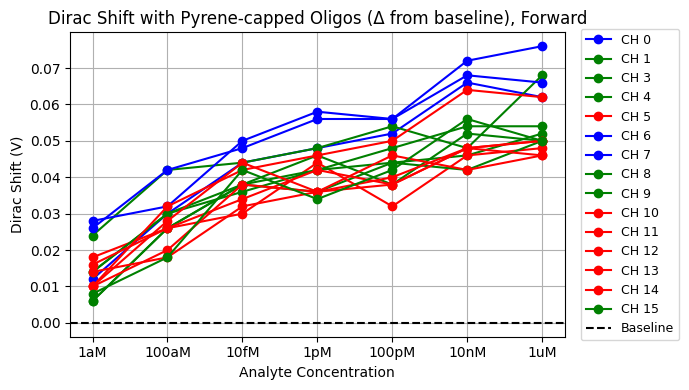

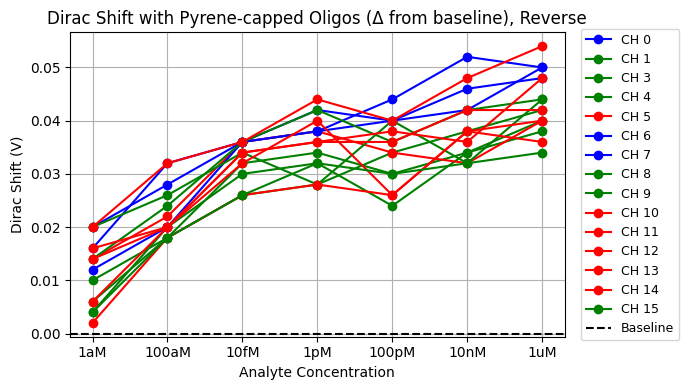

func1-w1d06-id.csv
func2-w1d06-oligo.csv


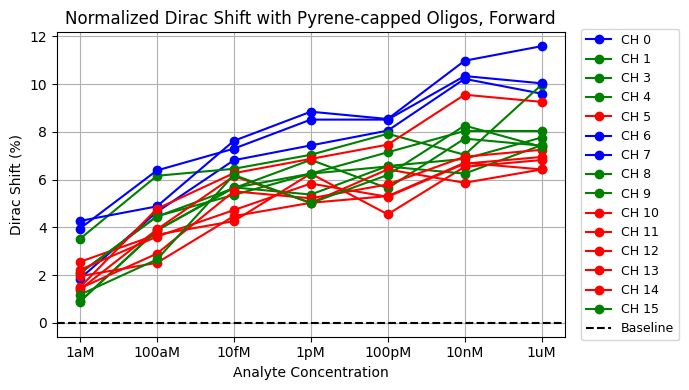

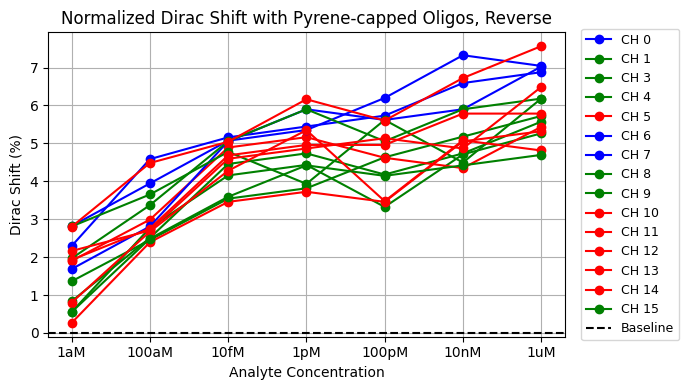

In [6]:
folder_path = "../data_pcb_smu/" + "2026-03-18 w1d06 dirac-tracking pyrene-capped pos-neg-ctrl/"
channels_to_omit = [2]
channel_colors = ['blue', 'green', 'blue', 'green', 'green', 'red', 'blue', 'blue', 'green', 'green', 'red', 'red', 'red', 'red', 'red', 'green'] 
func_steps = ["Initial", "Oligo"]
analyte_steps = ["1aM", "100aM", "10fM", "1pM", "100pM", "10nM", "1uM"]
func_title = "Functionalization Steps with Pyrene-capped Oligos"
analyte_title = "Dirac Shift with Pyrene-capped Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w2d13-initial.csv
func2-w2d13-ddt.csv
func3-w2d13-pbase.csv
func4-w2d13-oligo.csv


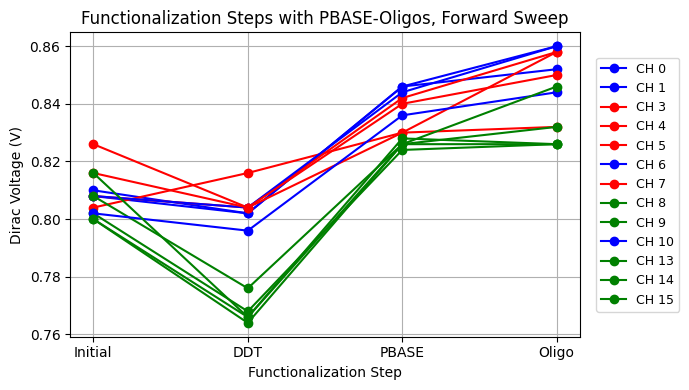

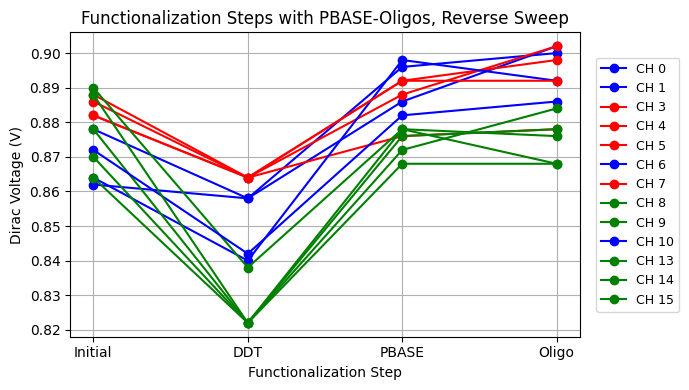

func1-w2d13-initial.csv
func2-w2d13-ddt.csv
func3-w2d13-pbase.csv
func4-w2d13-oligo.csv


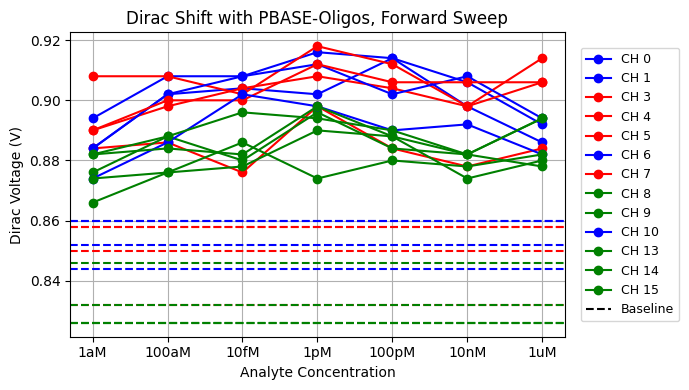

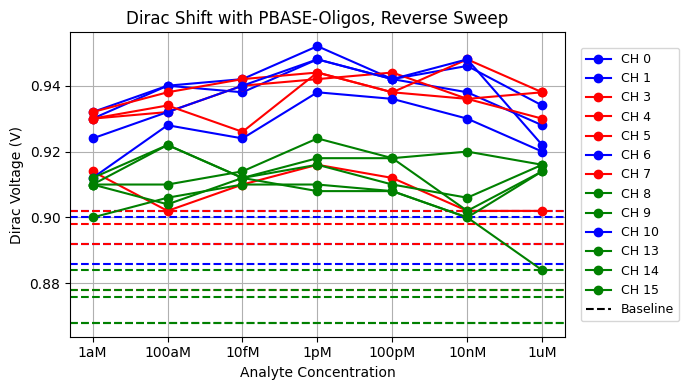

func1-w2d13-initial.csv
func2-w2d13-ddt.csv
func3-w2d13-pbase.csv
func4-w2d13-oligo.csv


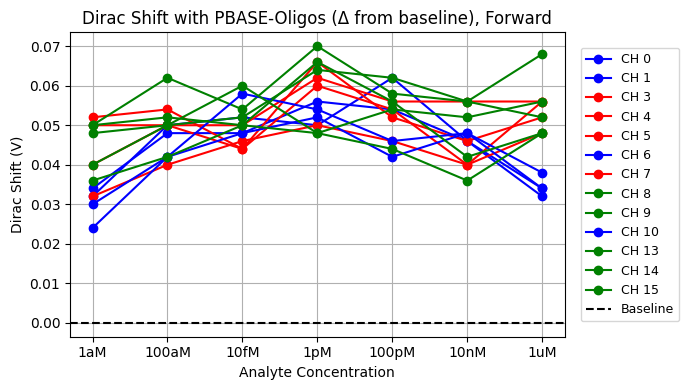

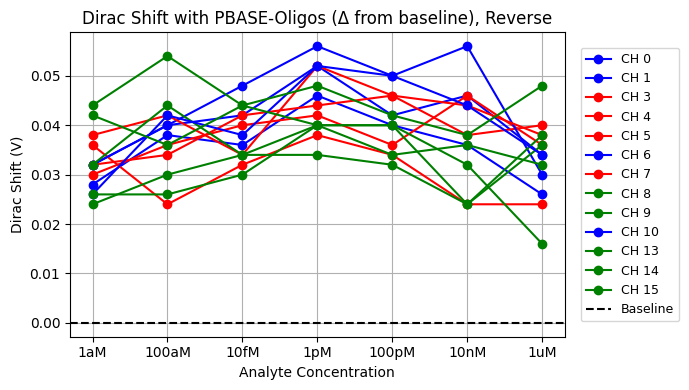

func1-w2d13-initial.csv
func2-w2d13-ddt.csv
func3-w2d13-pbase.csv
func4-w2d13-oligo.csv


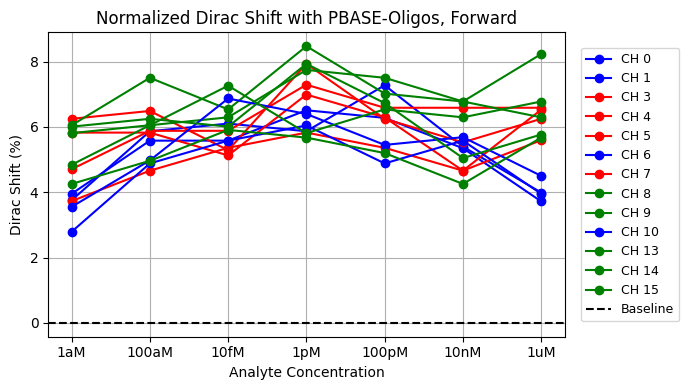

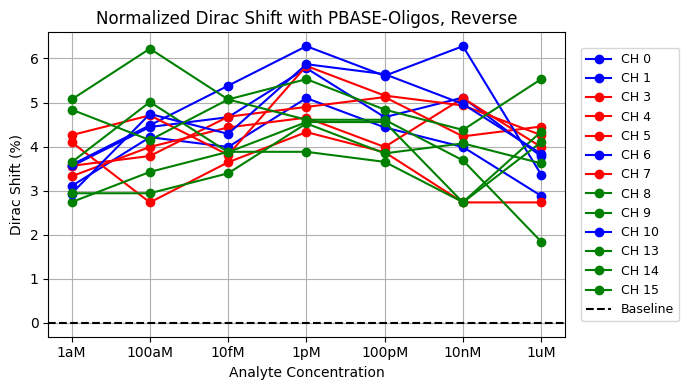

In [7]:
folder_path = "../data_pcb_smu/" + "2026-03-31 w2d13 dirac-tracking pbase-oligo pos-neg-ctrl/"
channels_to_omit = [11, 2, 12]

green = {8, 9, 12, 13, 14, 15}
blue = {0, 1, 6, 10, 11}
red = {2, 3, 4, 5, 7}
for i in range(16):
    channel_colors[i] = 'green' if i in green else 'blue' if i in blue else 'red'

func_steps = ["Initial", "DDT", "PBASE", "Oligo"]
analyte_steps = ["1aM", "100aM", "10fM", "1pM", "100pM", "10nM", "1uM"]
func_title = "Functionalization Steps with PBASE-Oligos"
analyte_title = "Dirac Shift with PBASE-Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w2d16-initial.csv
func2-w2d16-ddt.csv
func3-w2d16-pbase-oligo.csv


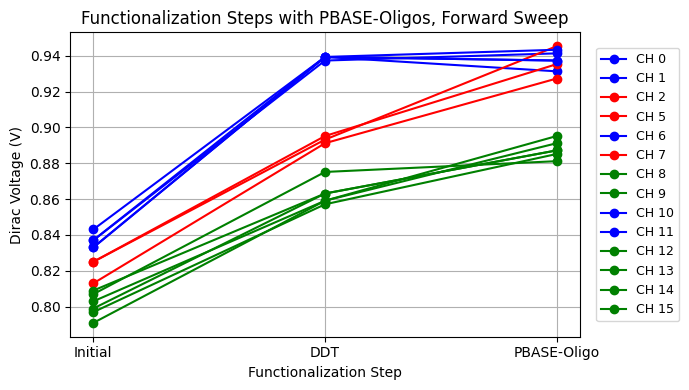

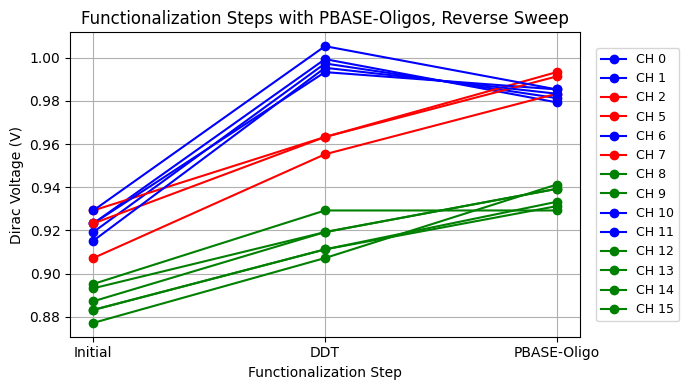

func1-w2d16-initial.csv
func2-w2d16-ddt.csv
func3-w2d16-pbase-oligo.csv


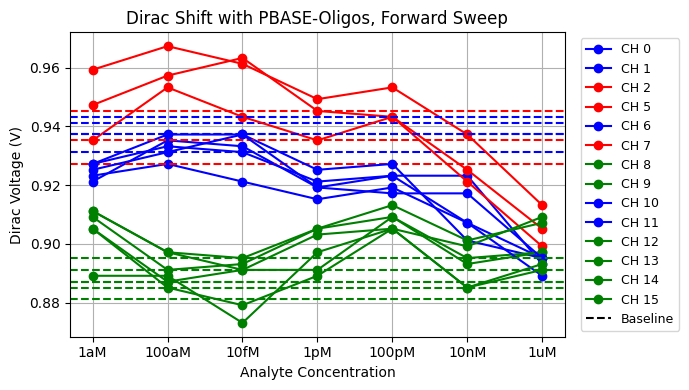

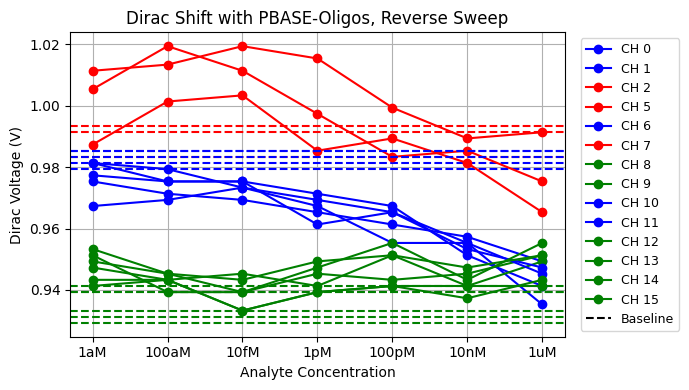

func1-w2d16-initial.csv
func2-w2d16-ddt.csv
func3-w2d16-pbase-oligo.csv


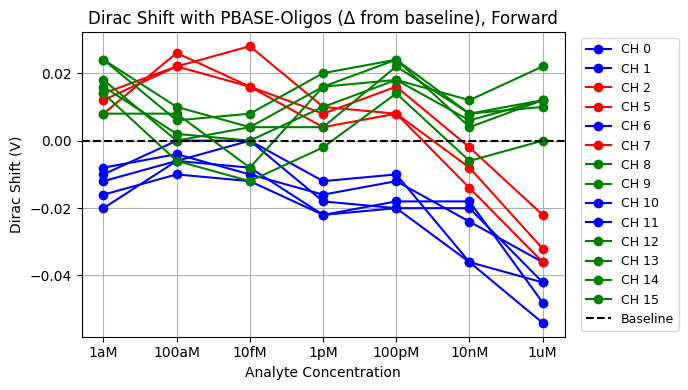

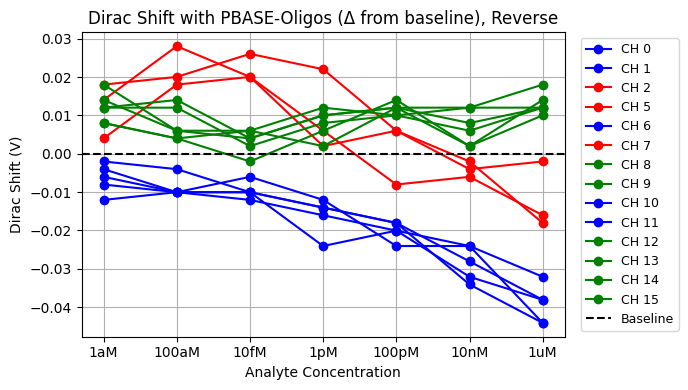

func1-w2d16-initial.csv
func2-w2d16-ddt.csv
func3-w2d16-pbase-oligo.csv


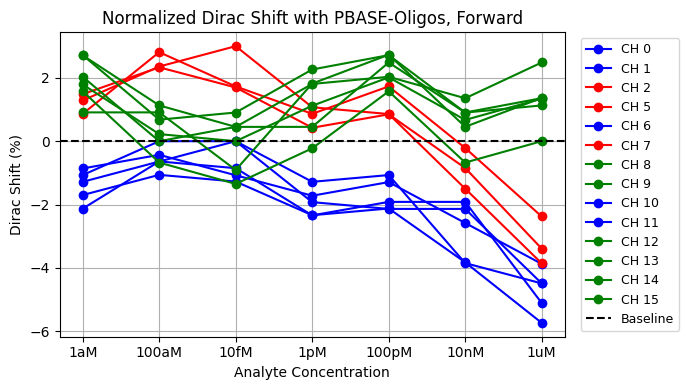

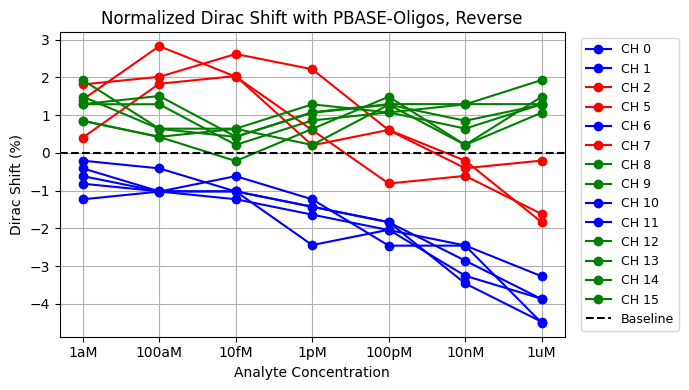

In [8]:
folder_path = "../data_pcb_smu/" + '2026-04-07 w2d16 dirac-tracking pbase-oligo pos-neg-ctrl/'
channels_to_omit = [3, 4]

green = {8, 9, 12, 13, 14, 15}
blue = {0, 1, 6, 10, 11}
red = {2, 3, 4, 5, 7}
for i in range(16):
    channel_colors[i] = 'green' if i in green else 'blue' if i in blue else 'red'

func_steps = ["Initial", "DDT", "PBASE-Oligo"]
analyte_steps = ["1aM", "100aM", "10fM", "1pM", "100pM", "10nM", "1uM"]
func_title = "Functionalization Steps with PBASE-Oligos"
analyte_title = "Dirac Shift with PBASE-Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w2d15-initial.csv
func2-w2d15-ddt.csv
func3-w2d15-pbase-oligo.csv


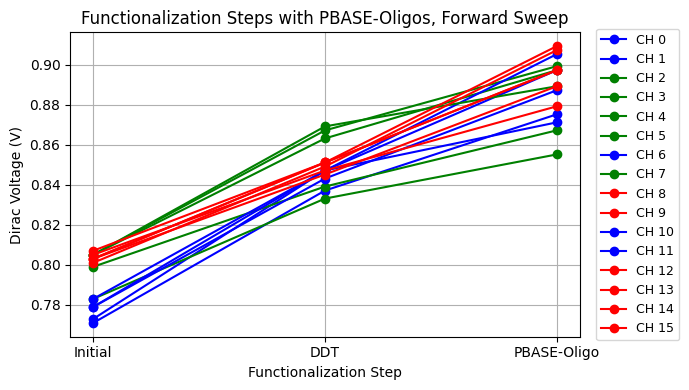

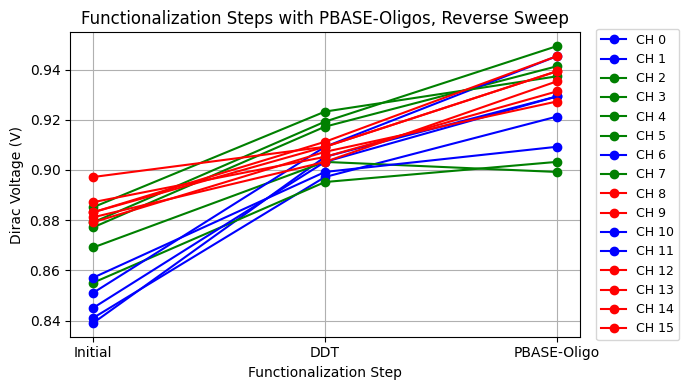

func1-w2d15-initial.csv
func2-w2d15-ddt.csv
func3-w2d15-pbase-oligo.csv


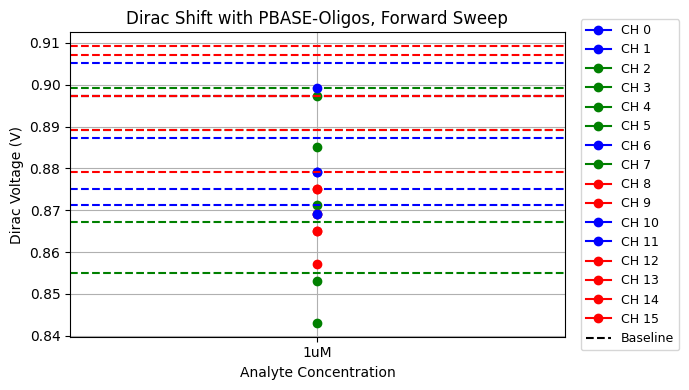

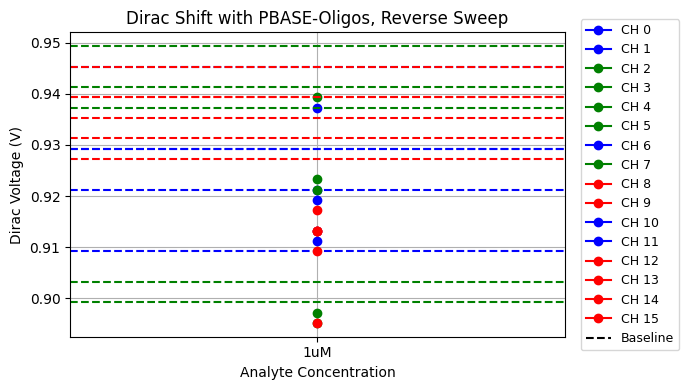

func1-w2d15-initial.csv
func2-w2d15-ddt.csv
func3-w2d15-pbase-oligo.csv


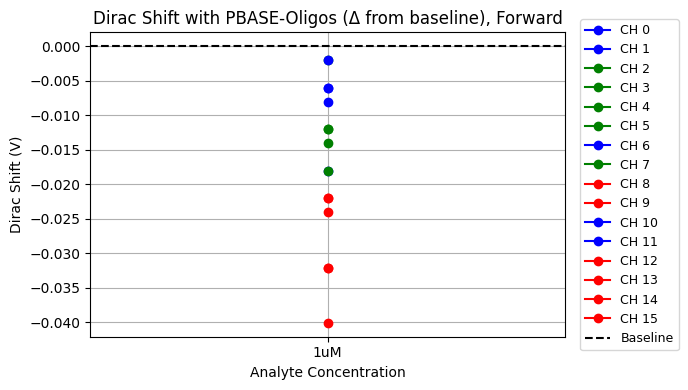

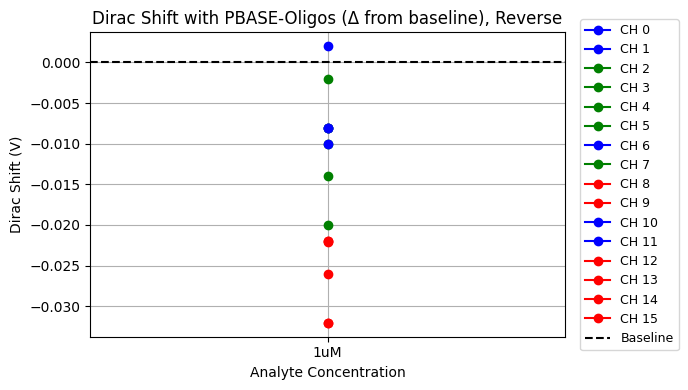

func1-w2d15-initial.csv
func2-w2d15-ddt.csv
func3-w2d15-pbase-oligo.csv


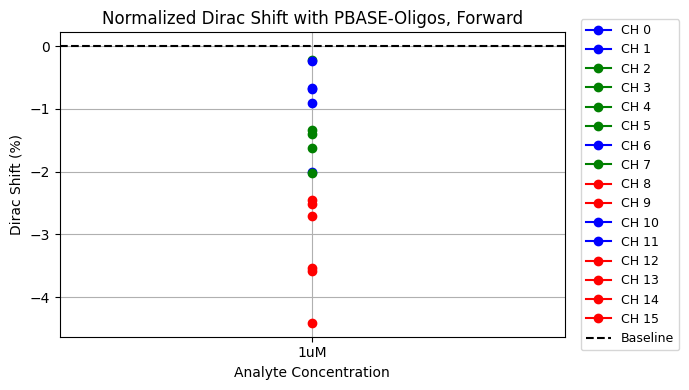

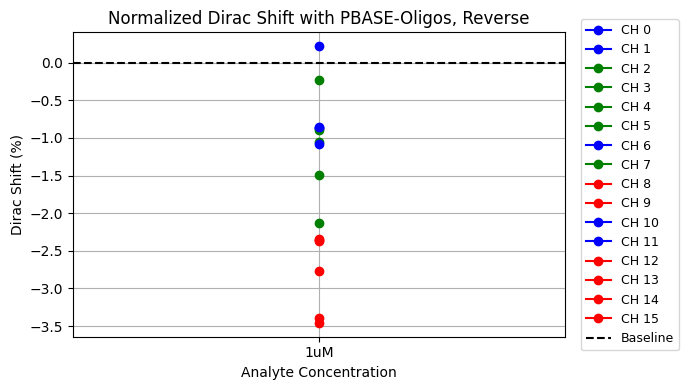

In [9]:
folder_path = "../data_pcb_smu/" + '2026-04-16 w2d15 dirac-tracking pbase-oligo pos-neg-ctrl/'

channels_to_omit = []

red = {8, 9, 12, 13, 14, 15}
blue = {0, 1, 6, 10, 11}
green = {2, 3, 4, 5, 7} 
for i in range(16):
    channel_colors[i] = 'green' if i in green else 'blue' if i in blue else 'red'

func_steps = ["Initial", "DDT", "PBASE-Oligo"]
analyte_steps = ["1uM"]
func_title = "Functionalization Steps with PBASE-Oligos"
analyte_title = "Dirac Shift with PBASE-Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w3d6-id.csv
func2-w3d6-pbase-oligo.csv
func3-w3d6-p01xPBS.csv


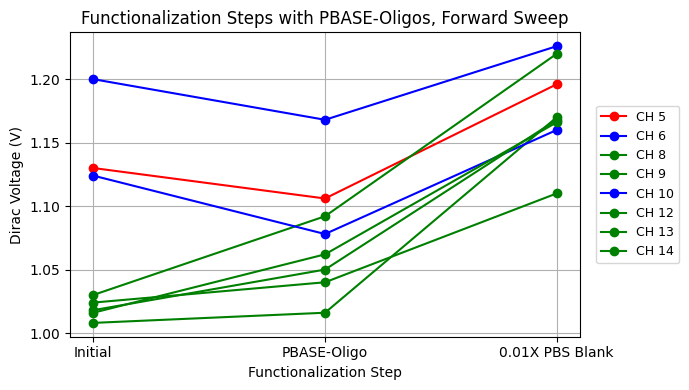

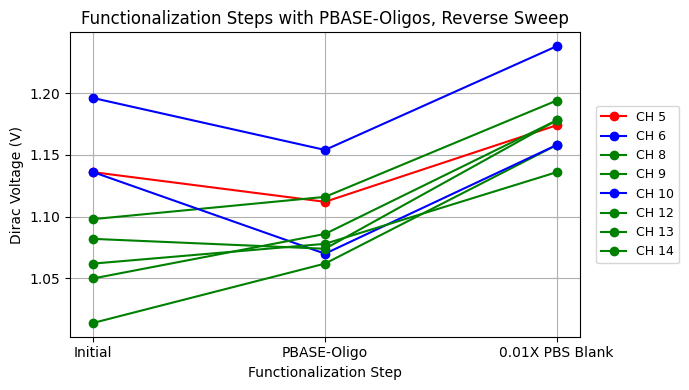

func1-w3d6-id.csv
func2-w3d6-pbase-oligo.csv
func3-w3d6-p01xPBS.csv


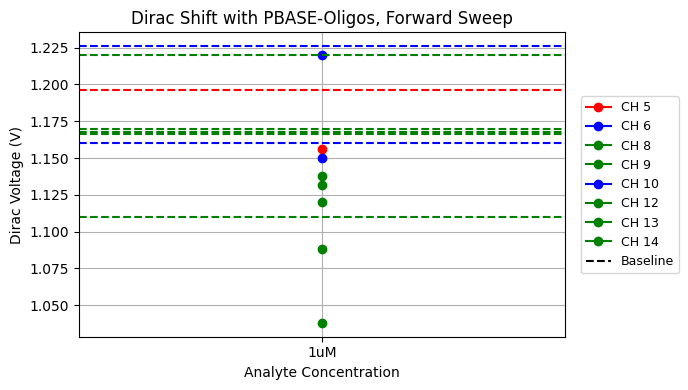

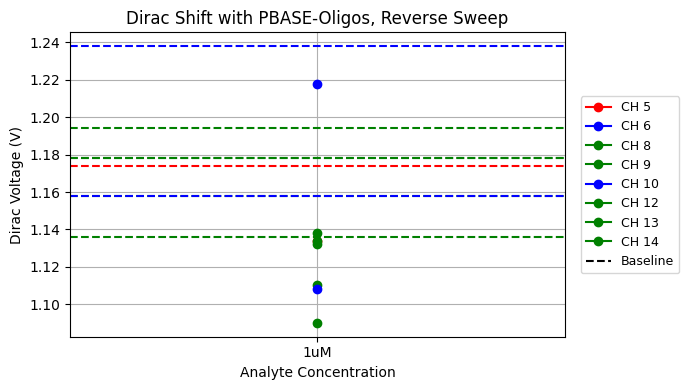

func1-w3d6-id.csv
func2-w3d6-pbase-oligo.csv
func3-w3d6-p01xPBS.csv


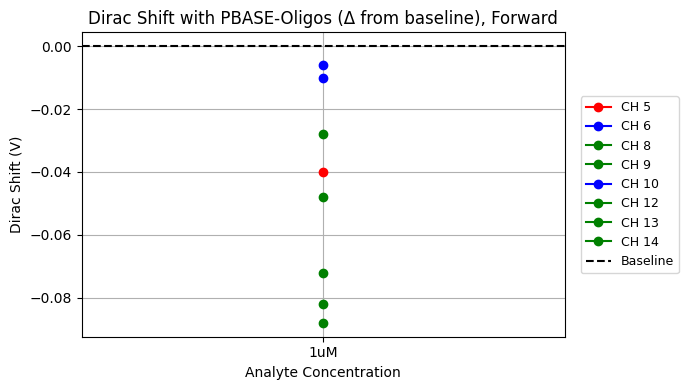

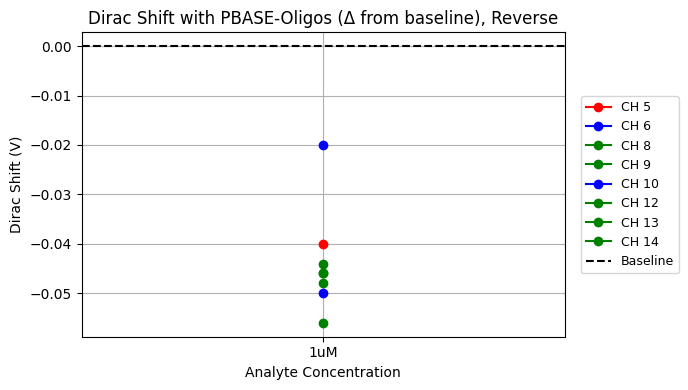

func1-w3d6-id.csv
func2-w3d6-pbase-oligo.csv
func3-w3d6-p01xPBS.csv


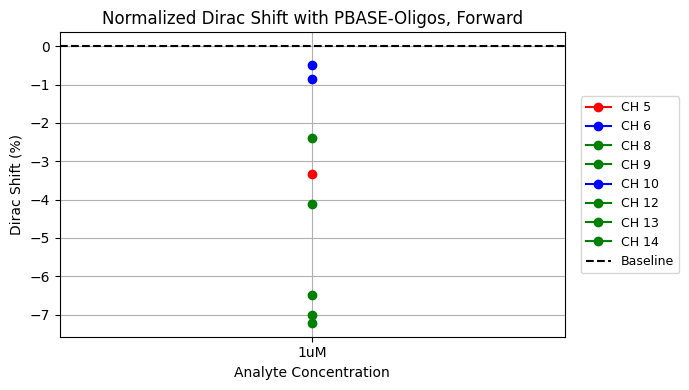

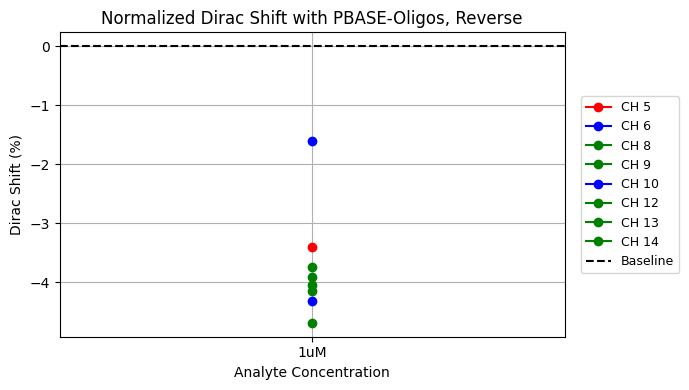

In [10]:
folder_path = "../data_pcb_smu/" + '2026-05-13 w3d6 dirac-tracking pbase-oligo pos-neg-ctrl/'

channels_to_omit = [0,1,2,3,4,7,11,15]

green = {8, 9, 12, 13, 14, 15}
blue = {0, 1, 6, 10, 11}
red = {2, 3, 4, 5, 7} 
for i in range(16):
    channel_colors[i] = 'green' if i in green else 'blue' if i in blue else 'red'

func_steps = ["Initial", "PBASE-Oligo", "0.01X PBS Blank"]
analyte_steps = ["1uM"]
func_title = "Functionalization Steps with PBASE-Oligos"
analyte_title = "Dirac Shift with PBASE-Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w7d3-id-ph7.csv


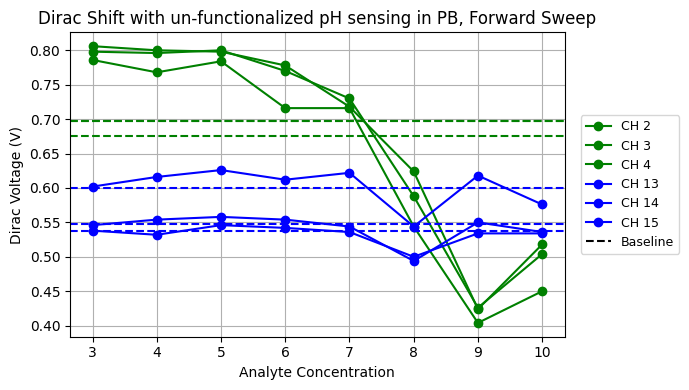

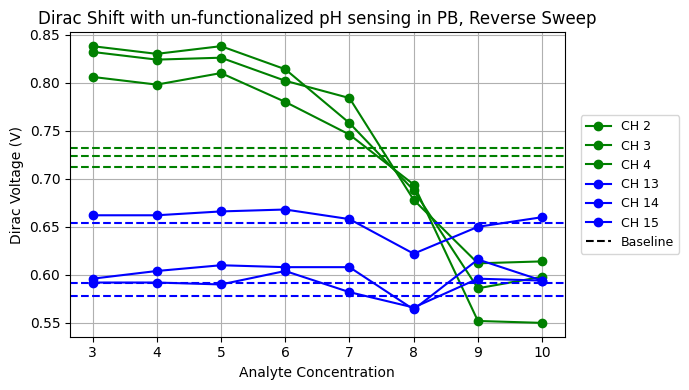

func1-w7d3-id-ph7.csv


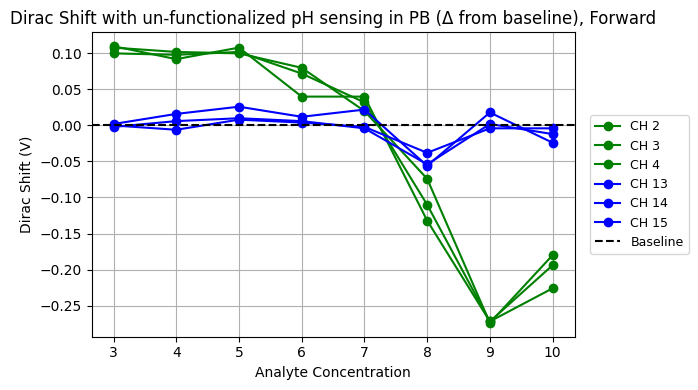

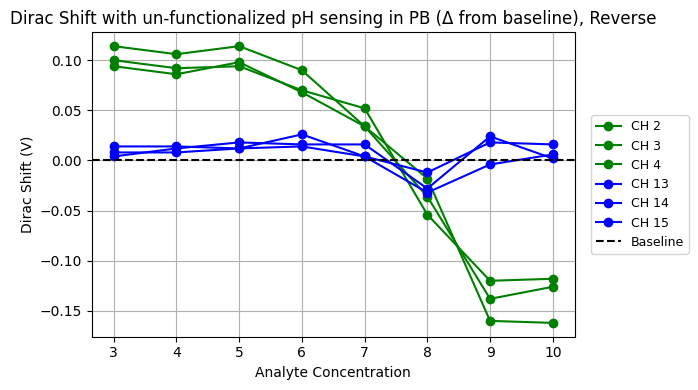

func1-w7d3-id-ph7.csv


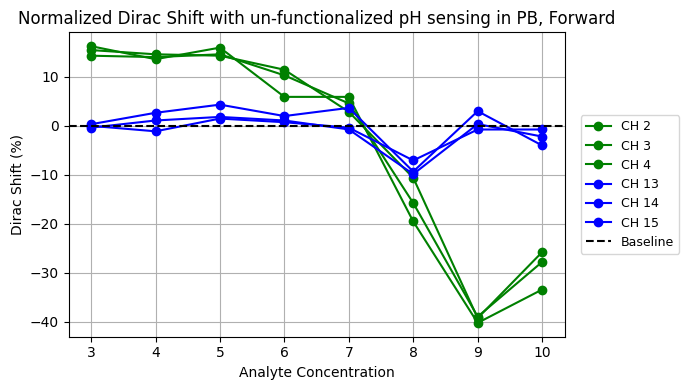

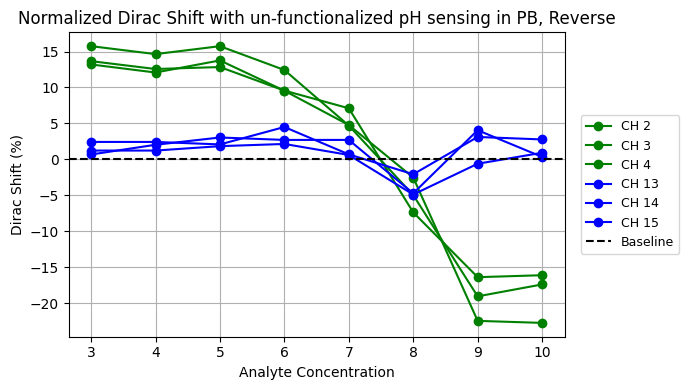

In [53]:
folder_path = "../data_pcb_smu/" + '2026-07-01 w7d6 dirac-tracking-and-time PB-pH pos-neg-ctrl/'

channels_to_omit = [5, 7, 8, 9, 11, 12, 10, 0, 1, 6]
channel_colors = {}

# pos ctrl: 2, 3, 4
# bad pos ctrl: 5, 7
# good neg ctrl: 0, 1, 6, 10, 13, 14, 15
# bad neg ctrl: 8, 9, 11, 12

# 0, 1, 6 are iffy


green = {2, 3, 4, 5, 7} 
blue = {0, 1, 6, 10, 11} | {8, 9, 12, 13, 14, 15}
for i in range(16):
    channel_colors[i] = 'green' if i in green else 'blue' if i in blue else 'blue'

func_steps = [] # ["Initial", "PBASE-Oligo", "0.01X PBS Blank"]
analyte_steps = [3, 4, 5, 6, 7, 8, 9, 10, 11]
func_title = [] #"Functionalization Steps with PBASE-Oligos"
analyte_title = "Dirac Shift with un-functionalized pH sensing in PB"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

# processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()



func1-w7d3-id.csv
func2-w7d3-pbase.csv
func3-w7d3-oligo.csv
func4-w7d3-p01x.csv


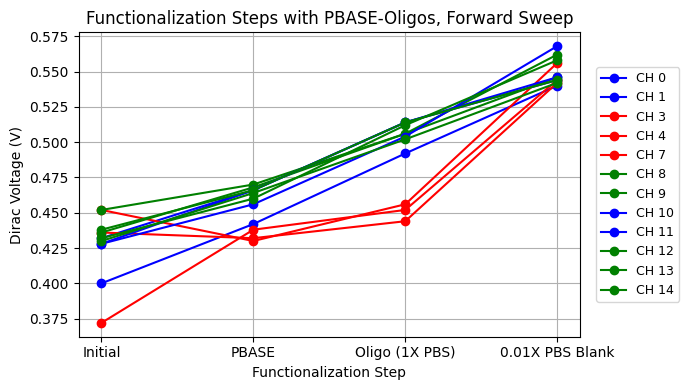

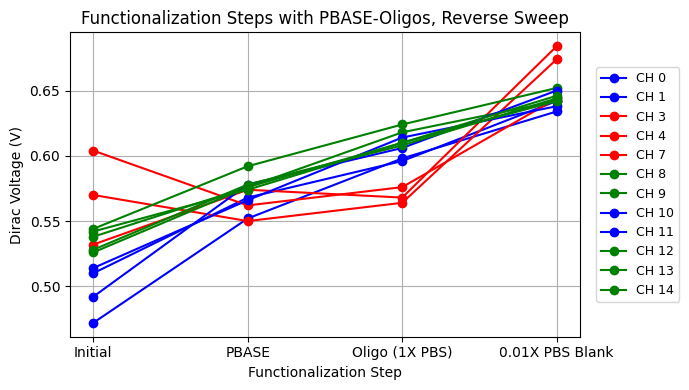

func1-w7d3-id.csv
func2-w7d3-pbase.csv
func3-w7d3-oligo.csv
func4-w7d3-p01x.csv


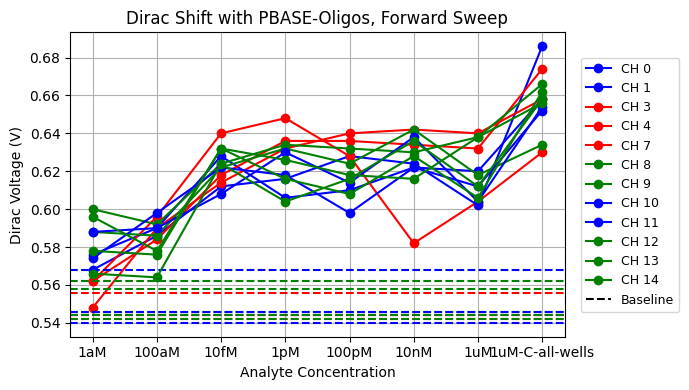

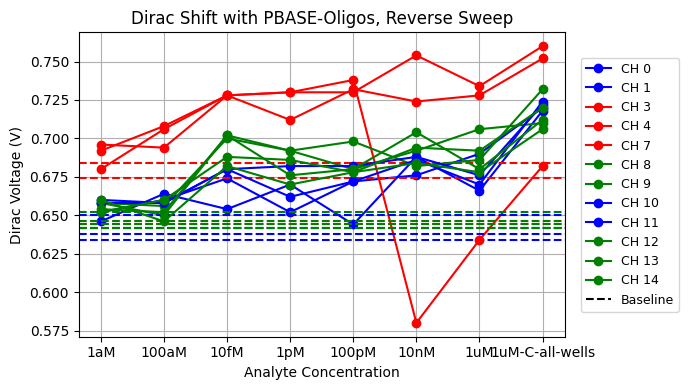

func1-w7d3-id.csv
func2-w7d3-pbase.csv
func3-w7d3-oligo.csv
func4-w7d3-p01x.csv


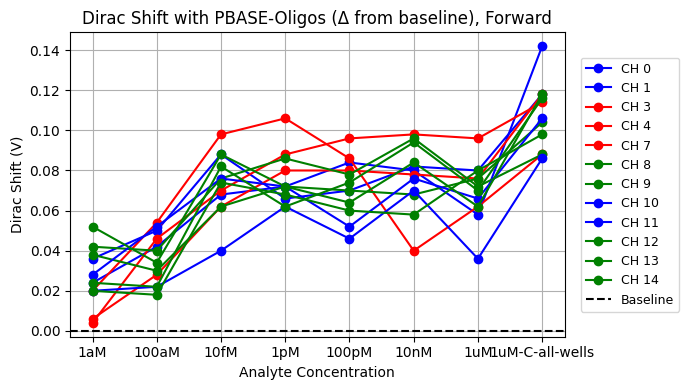

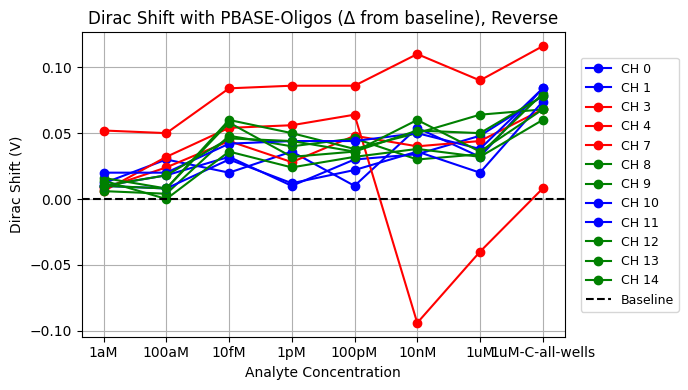

func1-w7d3-id.csv
func2-w7d3-pbase.csv
func3-w7d3-oligo.csv
func4-w7d3-p01x.csv


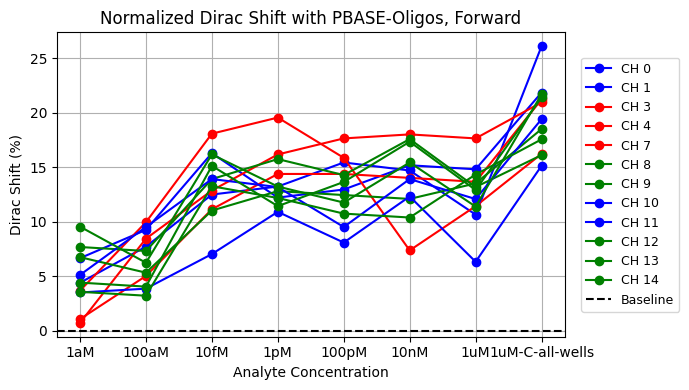

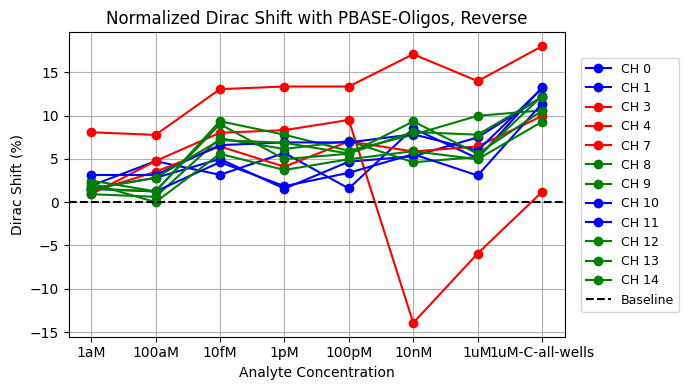

In [12]:
folder_path = "../data_pcb_smu/" + '2026-07-01 w7d3 dirac-tracking pbase-oligo pos-neg-ctrl/'

# well 3 has lower dirac point...
# no DDT
# last conc was 1uM spiked into every single well
# maybe next time, wash the well with the next concentration of analyte

channels_to_omit = [5, 15, 2, 6]

green = {8, 9, 12, 13, 14, 15}
blue = {0, 1, 6, 10, 11}
red = {2, 3, 4, 5, 7}
for i in range(16):
    channel_colors[i] = 'green' if i in green else 'blue' if i in blue else 'red'

func_steps = ["Initial", "PBASE", "Oligo (1X PBS)", "0.01X PBS Blank"]
analyte_steps = ["1aM", "100aM", "10fM", "1pM", "100pM", "10nM", "1uM", "1uM-C-all-wells"]
func_title = "Functionalization Steps with PBASE-Oligos"
analyte_title = "Dirac Shift with PBASE-Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w7d15-id.csv
func2-w7d15-pbase.csv
func3-w7d15-nano.csv
func4-w7d15-p01x.csv


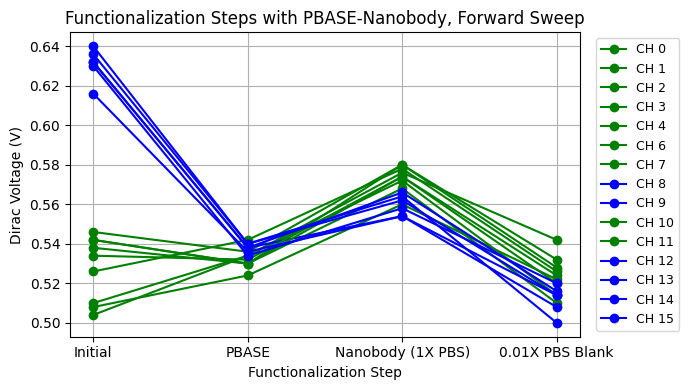

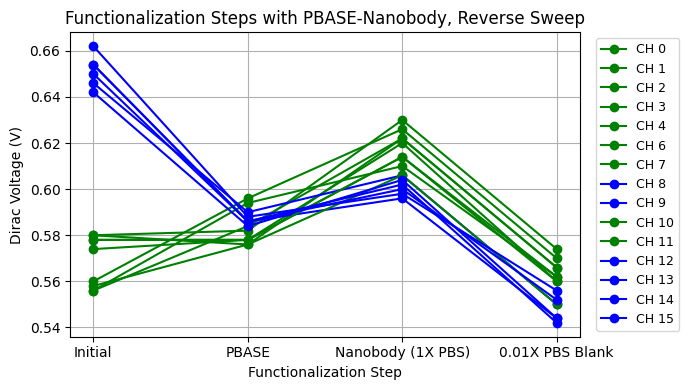

func1-w7d15-id.csv
func2-w7d15-pbase.csv
func3-w7d15-nano.csv
func4-w7d15-p01x.csv


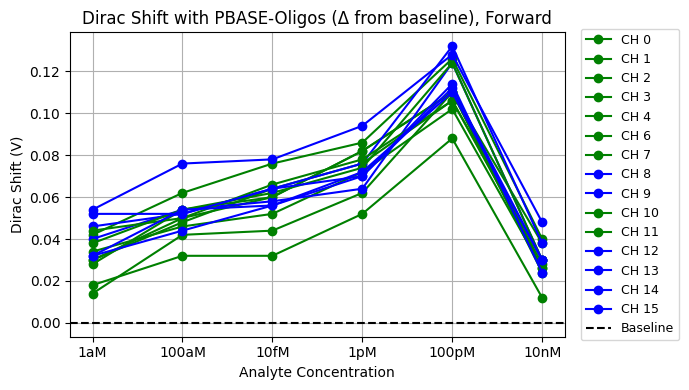

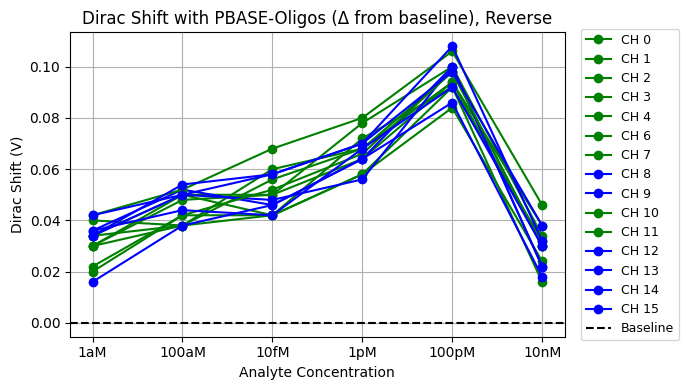

func1-w7d15-id.csv
func2-w7d15-pbase.csv
func3-w7d15-nano.csv
func4-w7d15-p01x.csv


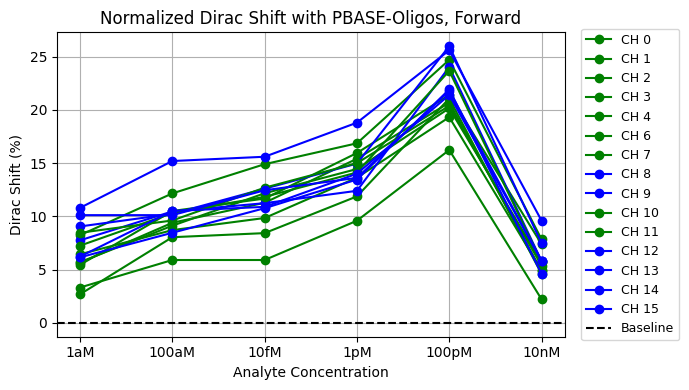

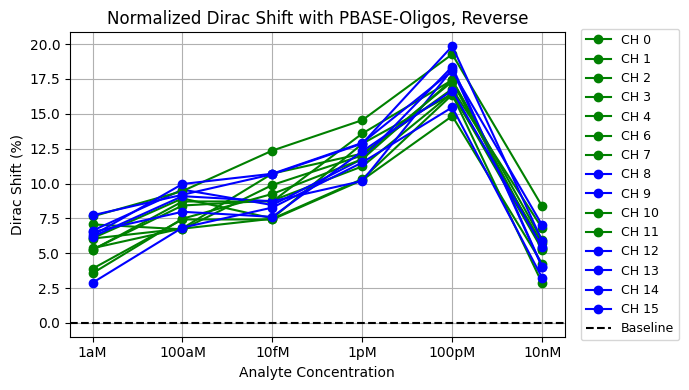

In [54]:
folder_path = "../data_pcb_smu/" + '2026-07-06 w7d15 dirac-tracking pbase-nano pos-blank-ctrl/'

channels_to_omit = [5]

blue = {8, 9, 12, 13, 14, 15}
green = {0, 1, 6, 10, 11} | {2, 3, 4, 5, 7}

for i in range(16):
    channel_colors[i] = 'green' if i in green else 'blue' if i in blue else 'red'

func_steps = ["Initial", "PBASE", "Nanobody (1X PBS)", "0.01X PBS Blank"]
analyte_steps = ["1aM", "100aM", "10fM", "1pM", "100pM", "10nM"]
func_title = "Functionalization Steps with PBASE-Nanobody"
analyte_title = "Dirac Shift with PBASE-Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

processor.plot_functionalization()
# processor.plot_analyte_abs()
processor.plot_analyte_abs_change()
processor.plot_analyte_norm()

func1-w7d12-id.csv
func2-w7d12-pbasenano.csv
func3-w7d12-p01xBaseline.csv


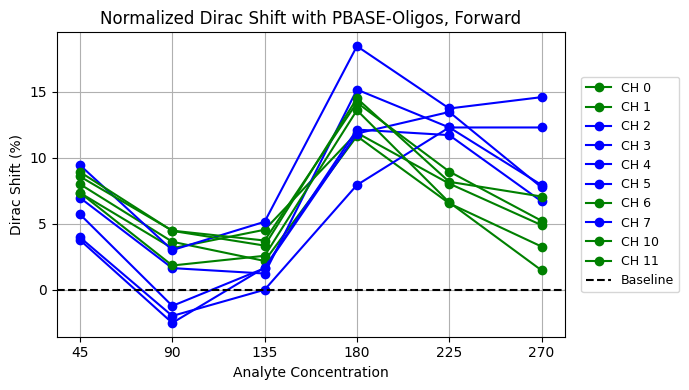

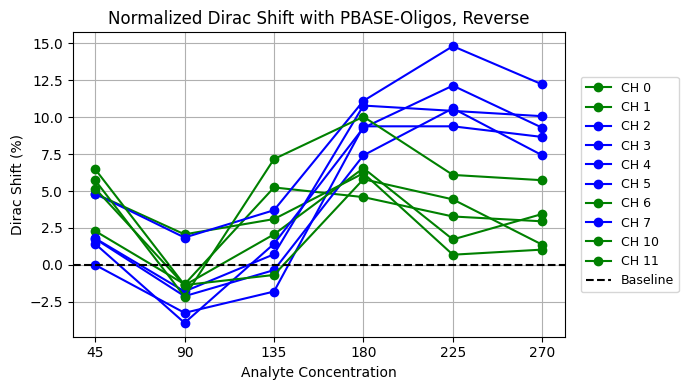

In [55]:
folder_path = "../data_pcb_smu/" + '2026-07-15 w7d12 dirac-tracking drift-bare-nano/'

channels_to_omit = [8,9,12,13,12,14,15]

green = {0, 1, 6, 10, 11}
blue = {2, 3, 4, 5, 7}

for i in range(16):
    channel_colors[i] = 'green' if i in green else 'blue' if i in blue else 'red'

func_steps = ["Initial", "PBASE+nano (1X PBS)", "0.01X PBS Blank"]
analyte_steps = [45, 90, 135, 180, 225, 270]
func_title = "Functionalization Steps with PBASE-Nanobody"
analyte_title = "Dirac Shift with PBASE-Oligos"

##############

processor = GFETDiracProcessor(
    folder_path,
    channels_to_omit,
    channel_colors,
    func_steps,
    analyte_steps,
    func_title,
    analyte_title
)

# processor.plot_functionalization()
# processor.plot_analyte_abs()
# processor.plot_analyte_abs_change()
processor.plot_analyte_norm()